## Nome: Caio Semblano Silva
## Matrícula: 621
---

# Atividade – Interpolação Polinomial

## Breve Explicação
A **interpolação polinomial** é um método numérico fundamental utilizado quando temos um conjunto de pontos conhecidos $(x_i, f(x_i))$ — normalmente obtidos por meio de resultados experimentais, tabelas ou medições de laboratório — e precisamos aproximar essa função desconhecida $f(x)$ por uma função polinomial $p_n(x)$ mais simples de manipular [cite: 1].

A condição básica da interpolação é que o polinômio $p_n(x)$ deve satisfazer a propriedade de passar exatamente por todos os pontos dados, ou seja:
$$p_n(x_i) = f(x_i), \quad para \ i = 0, 1, 2, ..., n$$

Conforme visto em aula, podemos determinar os coeficientes do polinômio interpolador resolvendo um **sistema de equações lineares** ou utilizando formulações específicas como o **Polinômio Interpolador de Lagrange**.

## Funções Auxiliares

In [3]:
# Importando bibliotecas essenciais
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Função de Apoio para Interpolação de Lagrange
def interpolacao_lagrange(x_pontos, y_pontos, x_val):
    """
    Calcula o valor do polinômio interpolador de Lagrange no ponto x_val.
    x_pontos: array com os valores de x conhecidos
    y_pontos: array com os valores de y conhecidos
    x_val: ponto onde se deseja estimar o valor
    """
    n = len(x_pontos)
    soma = 0.0
    for i in range(n):
        termo = y_pontos[i]
        for j in range(n):
            if j != i:
                termo = termo * (x_val - x_pontos[j]) / (x_pontos[i] - x_pontos[j])
        soma += termo
    return soma

#---
# Parte Prática

## Contexto 1 – Desempenho de Robôs na FETIN
Durante os testes preparatórios para a **FETIN (Feira Tecnológica do Inatel)**, uma equipe de engenharia coletou dados do torque aplicado em um motor de tração de um robô autônomo em função da velocidade angular de teste.

Os dados medidos em laboratório foram organizados na tabela abaixo:

| Velocidade Angular (rad/s) | 1.0 | 2.0 | 3.0 |
|----------------------------|-----|-----|-----|
| Torque Medido (N.m)        | 2.5 | 6.0 | 11.5|

### Questão 1 – Sistema de Equações Lineares
1. Determine analiticamente ou via código o polinômio interpolador de 2º grau $p(x) = a_0 + a_1x + a_2x^2$ que passa exatamente pelos 3 pontos da tabela da FETIN, montando o sistema linear correspondente.

In [5]:
# Resolva a Questão 1 aqui (Monte o sistema linear ou utilize np.linalg.solve para encontrar a0, a1 e a2)
x_fetin = np.array([1.0, 2.0, 3.0])
y_fetin = np.array([2.5, 6.0, 11.5])

# Dica: Matriz de Vandermonde ou coeficientes via np.polyfit com grau 2 (que gera a interpolação exata para 3 pontos)
V = np.vander(x_fetin, increasing=True)

coeficientes = np.linalg.solve(V, y_fetin)
a0, a1, a2 = coeficientes

print(f"Coeficientes encontrados: a0={a0:.1f}, a1={a1:.1f}, a2={a2:.1f}")
print(f"Polinômio: p(x) = {a0:.1f} + {a1:.1f}x + {a2:.1f}x^2")

Coeficientes encontrados: a0=1.0, a1=0.5, a2=1.0
Polinômio: p(x) = 1.0 + 0.5x + 1.0x^2


2. Utilizando o polinômio encontrado, calcule uma estimativa para o torque do robô quando a velocidade angular for de $x = 2.5 \text{ rad/s}$.

In [6]:
# Calcule a estimativa para x = 2.5 aqui
x_estimado = 2.5
torque_estimado = a0 + a1 * x_estimado + a2 * (x_estimado**2)

print(f"Torque estimado para x = {x_estimado} rad/s: {torque_estimado} N.m")

Torque estimado para x = 2.5 rad/s: 8.5 N.m


## Contexto 2 – Hackathon Inatel & Coneti
Em uma maratona de programação e inovação (**Hackathon do Inatel**), um grupo de alunos precisa modelar o consumo de banda de uma rede de sensores IoT instalada no campus inteligente. A tabela abaixo relaciona o tempo de operação (em horas) com o tráfego medido de dados (em GB):

| Tempo (h)       | 0   | 1   | 3   |
|-----------------|-----|-----|-----|
| Tráfego (GB)    | 1.2 | 2.5 | 8.1 |

### Questão 2 – Método de Lagrange
1. Implemente ou utilize a função de Lagrange fornecida para encontrar o valor aproximado do tráfego de dados no instante $t = 2.0 \text{ horas}$.

In [7]:
# Resolva a Questão 2 usando o método de Lagrange para t = 2.0
x_hack = np.array([0, 1, 3])
y_hack = np.array([1.2, 2.5, 8.1])

# Exemplo de chamada: valor_estimado = interpolacao_lagrange(x_hack, y_hack, 2.0)
valor_estimado = interpolacao_lagrange(x_hack, y_hack, 2.0)
print(f"O tráfego de dados estimado em t = 2.0 horas é de {valor_estimado:.2f} GB")

O tráfego de dados estimado em t = 2.0 horas é de 4.80 GB


2. Plote o gráfico comparando os pontos experimentais do Hackathon e a curva do polinômio interpolador gerado no intervalo de $0$ a $3$ horas.

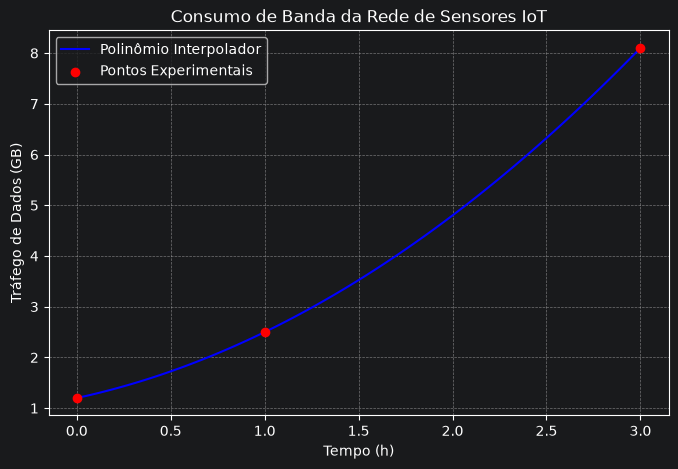

In [8]:
# Plote o gráfico aqui utilizando matplotlib
x_curva = np.linspace(0, 3, 100)
y_curva = [interpolacao_lagrange(x_hack, y_hack, x) for x in x_curva]

plt.figure(figsize=(8, 5))

plt.plot(x_curva, y_curva, label='Polinômio Interpolador', color='blue')
plt.scatter(x_hack, y_hack, color='red', zorder=5, label='Pontos Experimentais')

plt.title('Consumo de Banda da Rede de Sensores IoT')
plt.xlabel('Tempo (h)')
plt.ylabel('Tráfego de Dados (GB)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


---
# Parte Teórica

1. Explique com suas próprias palavras qual é a principal diferença conceitual entre **Interpolação Polinomial** e **Ajuste de Curvas por Mínimos Quadrados**.

**Resposta:** A principal diferença é a rigidez com que a curva trata as marcações. Na interpolação polinomial, o modelo matemático é construído para passar exatamente em cima de todos os pontos experimentais conhecidos, zerando o erro residual naquelas posições. Já no ajuste por mínimos quadrados, o objetivo é capturar a tendência geral do conjunto, minimizando as distâncias entre a curva e os pontos reais, o que é ideal para lidar com dados ruidosos ou incertos, já que a linha traçada não precisa tocar em cada medição individualmente


2. O que ocorre com o grau do polinômio interpolador à medida que adicionamos mais pontos experimentais ao conjunto de dados? Cite uma possível desvantagem prática disso.

**Resposta:** Conforme adicionamos mais pontos experimentais ao nosso conjunto de dados, o grau do polinômio interpolador cresce na mesma proporção. Na prática, isso se torna um problema grave porque polinômios de graus muito altos tendem a sofrer com o Fenômeno de Runge, gerando oscilações extremas e instáveis na curva nos espaços entre os pontos conhecidos e tornando as estimativas intermediárias totalmente irreais e imprevisíveis.


3. Qual é a diferença entre **Interpolação** e **Extrapolação**, considerando a posição do ponto que se deseja estimar em relação ao intervalo dos dados conhecidos?

**Resposta:** A distinção fundamental está na posição do ponto que queremos descobrir em relação aos limites da nossa amostra. A interpolação ocorre quando estimamos um valor que está contido de forma segura dentro do intervalo dos nossos dados conhecidos (entre a menor e a maior leitura), enquanto a extrapolação tenta prever um resultado para uma região externa a essa faixa, sendo uma abordagem bem mais arriscada por presumir cegamente que o padrão matemático vai se manter o mesmo em um cenário ainda não observado.
